How does activity vary between the different cerebral areas ?

In [10]:
import io
import numpy as np
import requests # HTTPS request API 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### What are we working with?
Let's have a look at the metadata file and the architecture of the downloaded sy5xt file, which has only 1 column: the spike times of these 734 neurons. Let's import the dataset and check if it's correctly loaded

In [6]:
r = requests.get('https://osf.io/sy5xt/download') 

if r.status_code != 200: 
    # 200 is the validation code that confirms that the request has been successful
    print('Download failed')
else:
    data = np.load(io.BytesIO(r.content), allow_pickle=True)  # pickle allows np.load to load complex data (several tables), essential here as all neurons have different numbers of spikes
    print("available keys:", data.files)
    
    spike_times = data['spike_times'] # technically useless because only one column

    # Description shows type and length(s) of the dataset
    print(f"Data type : {type(spike_times)}")
    print(f"Data col lengths : {len(spike_times)}")

    # Afficher la forme de chaque tableau de spikes
    print("\nData shape for the 5 first neurons :")
    for i in range(min(5, len(spike_times))):
        print(f"Neuron {i+1} : {spike_times[i].shape} (Spike number : {len(spike_times[i])})")

    print(f"Loaded table : {len(spike_times)} neurons")

available keys: ['spike_times']
Data type : <class 'numpy.ndarray'>
Data col lengths : 734

Data shape for the 5 first neurons :
Neuron 1 : (826,) (Spike number : 826)
Neuron 2 : (2818,) (Spike number : 2818)
Neuron 3 : (3953,) (Spike number : 3953)
Neuron 4 : (646,) (Spike number : 646)
Neuron 5 : (1115,) (Spike number : 1115)
Loaded table : 734 neurons


Example with the first neuron, and plot of its first discharges

In [7]:
neuron_0 = spike_times[0] # Let's look at the first neuron's spike time
print(f"Number of spikes for this neuron : {len(neuron_0)}")
print(f"First discharge instants : {neuron_0[:10]}")

Number of spikes for this neuron : 826
First discharge instants : [  0.8149    14.822467  24.9646    25.1436    38.8709    50.8208
  54.806866  59.511833  80.47037  127.09637 ]


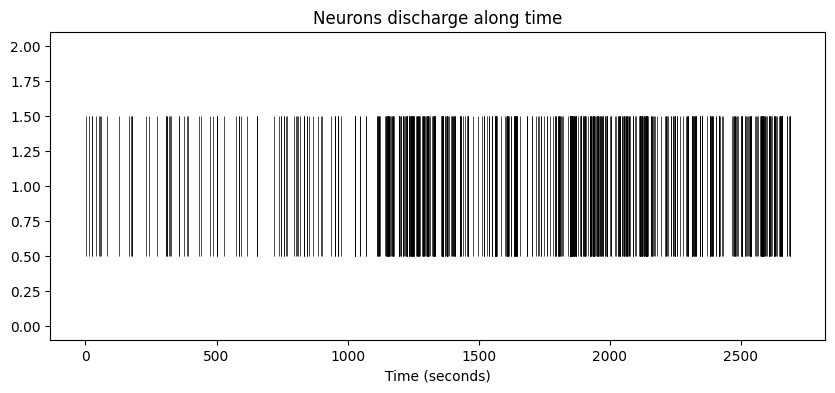

In [8]:
plt.figure(figsize=(10,4))
plt.eventplot(spike_times[0], color='black', linewidths=0.5)
plt.xlabel("Time (seconds)")
plt.title("First euron discharge along time")
plt.show()

Test with the 20 first neurons

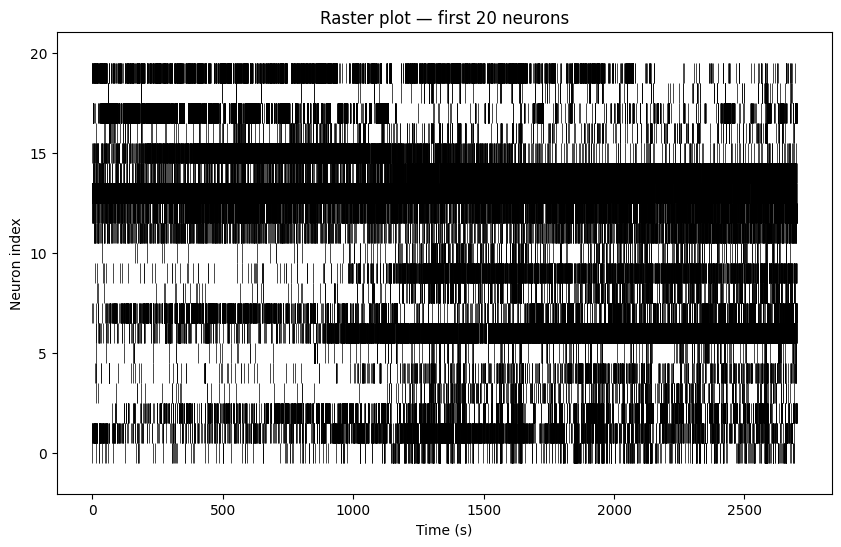

In [11]:
n_neurons_to_plot = 20 # Select the first 20 neurons to keep the plot readable

plt.figure(figsize=(10,6))
plt.eventplot(spike_times[:n_neurons_to_plot], color='black', linewidths=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Neuron index")
plt.title(f"Raster plot — first {n_neurons_to_plot} neurons")
plt.show()

With this only document, the range of question is quite limited, thus, we can go for statistical questions that can be answered with neuron spikes data only. We can compute the basic metrics of neurons like :
Time window between the first and last electrical discharge: "neuron activation time", but more commonly called " spike train duration" or "active firing period"
The firing rate in Hz, i.e., the number of neuron spikes divided by the time window.
The Inter-Spike Interval (pretty easy to figure out), as a table. Its coefficient of variation, basically as a first regularity measure (close to 0 very stable, close to 1 very random discharges).

In [7]:
results = []

for i, spikes in enumerate(spike_times):
    if len(spikes) < 2:
        continue  # on ignore les neurones trop silencieux
    
    duration = spikes[-1] - spikes[0]          # active firing period
    n_spikes = len(spikes)
    mean_rate = n_spikes / duration if duration > 0 else 0   # firing rate, Hz
    
    isi = np.diff(spikes)                      # inter-spike intervals
    mean_isi = np.mean(isi)
    cv_isi = np.std(isi) / mean_isi if mean_isi > 0 else np.nan   # variation
    
    results.append({
        'neuron_id': i,
        'n_spikes': n_spikes,
        'duration_s': duration,
        'mean_rate_Hz': mean_rate,
        'mean_isi_s': mean_isi,
        'cv_isi': cv_isi
    })

df = pd.DataFrame(results)
print(df.describe().round(3))
print(f"\nNombre de neurones analysés : {len(df)}")

       neuron_id    n_spikes  duration_s  mean_rate_Hz  mean_isi_s   cv_isi
count    734.000     734.000     734.000       734.000     734.000  734.000
mean     366.500   10319.351    2674.463         3.833       1.440    2.420
std      212.032   14749.342     117.732         5.461       2.576    1.867
min        0.000     118.000    1045.694         0.047       0.022    0.633
25%      183.250    1894.750    2687.719         0.707       0.201    1.451
50%      366.500    5128.000    2697.600         1.904       0.525    1.885
75%      549.750   13384.750    2699.665         4.972       1.415    2.647
max      733.000  125324.000    2700.183        46.420      21.305   21.931

Nombre de neurones analysés : 734


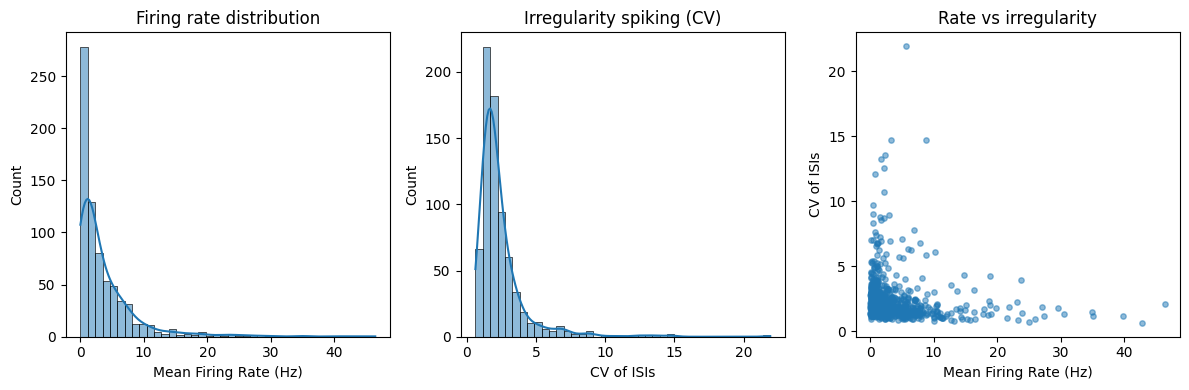

In [11]:
# Visualisation of neuron discharge distributions
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['mean_rate_Hz'], bins=40, kde=True)
plt.xlabel('Mean Firing Rate (Hz)')
plt.title('Firing rate distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['cv_isi'].dropna(), bins=40, kde=True)
plt.xlabel('CV of ISIs')
plt.title('Spiking irregularity (CV)')

plt.subplot(1, 3, 3)
plt.scatter(df['mean_rate_Hz'], df['cv_isi'], alpha=0.5, s=15)
plt.xlabel('Mean Firing Rate (Hz)')
plt.ylabel('CV of ISIs')
plt.title('Rate vs irregularity')

plt.tight_layout()
plt.show()

In [9]:
# Téléchargement des 3 parties
urls = [
    "https://osf.io/agvxh/download",  # part 0
    "https://osf.io/uv3mw/download",  # part 1
    "https://osf.io/ehmw2/download"   # part 2
]

alldat = np.array([])
for i, url in enumerate(urls):
    r = requests.get(url)
    if r.status_code == 200:
        dat = np.load(io.BytesIO(r.content), allow_pickle=True)['dat']
        alldat = np.hstack((alldat, dat)) if alldat.size else dat
        print(f"Part {i} loaded")
    else:
        print(f"Failed part {i}")

print(f"Nombre de sessions : {len(alldat)}")

Part 0 loaded
Part 1 loaded
Part 2 loaded
Nombre de sessions : 39
